In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud 

# **1. EDA**

In [2]:
df_facebook = pd.read_excel('../datasets/dataset_facebook-comments-scraper_2026-03-18_21-19-55-636.xlsx')
df_instagram = pd.read_excel('../datasets/dataset_instagram-comment-scraper_2026-03-18_22-30-04-045.xlsx')
df_tiktok = pd.read_excel('../datasets/dataset_tiktok-comments-scraper_2026-03-18_21-17-10-607.xlsx')

In [3]:
print('DATASET FACEBOOK')
display(df_facebook.head())
display(df_facebook.info())

DATASET FACEBOOK


,postTitle,postDescription,text,likesCount,facebookUrl
0,A1,B1,Baca selengkapnya di sini: https://www.harapan...,C1,E1
1,A2,B2,pemecah rekor baru kali ini ada THR..DI Anjuk,C2,E2
2,A3,B3,Cung nu korban Amplop 100 rb,C3,E3
3,A4,B4,Singhoreng teu begug mimpin tasik,C4,E4
4,A5,B5,Kade hilap joging,C5,E5


<class 'pandas.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   postTitle        345 non-null    str  
 1   postDescription  345 non-null    str  
 2   text             340 non-null    str  
 3   likesCount       345 non-null    str  
 4   facebookUrl      345 non-null    str  
dtypes: str(5)
memory usage: 13.6 KB


None

In [4]:
print('DATASET INSTAGRAM')
display(df_instagram.head())
display(df_instagram.info())

DATASET INSTAGRAM


,id,text,timestamp,ownerUsername,ownerProfilePicUrl,postUrl
0,A1,"Hatur nuhun penjelasan na Pak Wali. Mung izin,...",2026-03-18T12:32:41.000Z,D1,D1,D1
1,A2,Sing tiasa we pak pertanggung jawabkeun di akh...,2026-03-18T12:53:59.000Z,D2,D2,D2
2,A3,Kela pameng nuju pace 5,2026-03-18T16:21:07.000Z,D3,D3,D3
3,A4,THR asn pan dana na ti pusat bro sanes ngangge...,2026-03-18T13:36:58.000Z,D4,D4,D4
4,A5,Dengan tdk mengurangi rasa hormat kami pada ja...,2026-03-18T13:55:58.000Z,D5,D5,D5


<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id                  120 non-null    str  
 1   text                118 non-null    str  
 2   timestamp           120 non-null    str  
 3   ownerUsername       120 non-null    str  
 4   ownerProfilePicUrl  120 non-null    str  
 5   postUrl             120 non-null    str  
dtypes: str(6)
memory usage: 5.8 KB


None

In [5]:
print('DATASET TIKTOK')
display(df_tiktok.head())
display(df_tiktok.info())

DATASET TIKTOK


,text,diggCount,replyCommentTotal,createTimeISO,uniqueId,videoWebUrl,uid,cid,avatarThumbnail
0,asa te boga walikota..hanya KDM yg ku punya,B1,C1,2026-03-17T15:07:56.000Z,E1,F1,G1,H1,I1
1,sedih gara gara bapak ini,B2,C2,2026-03-17T13:43:56.000Z,E2,F2,G2,H2,I2
2,"hade goreng ku basa, ieu mah Pareum we eweuh k...",B3,C3,2026-03-17T14:11:12.000Z,E3,F3,G3,H3,I3
3,Ciamis ts cair Minggu kmari .Tasik mah kmha ce...,B4,C4,2026-03-17T12:31:49.000Z,E4,F4,G4,H4,I4
4,nyesel milih dia,B5,C5,2026-03-17T20:43:23.000Z,E5,F5,G5,H5,I5


<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   text               31 non-null     str  
 1   diggCount          34 non-null     str  
 2   replyCommentTotal  34 non-null     str  
 3   createTimeISO      34 non-null     str  
 4   uniqueId           34 non-null     str  
 5   videoWebUrl        34 non-null     str  
 6   uid                34 non-null     str  
 7   cid                34 non-null     str  
 8   avatarThumbnail    34 non-null     str  
dtypes: str(9)
memory usage: 2.5 KB


None

Ketiga dataset diatas merupakan hasil scraping. Namun pada research-original peneliti melakukan mengambilan data secara manual dengan cara melakukan copy-paste terhadap beberapa komentar (instagram dan tiktok) mengenai postingan yang relevan dengan isu yang menjadi objek penelitian. Cara ini dilakukan dikarenakan keadaan SDM atau peneliti mengalami kendala secara teknis.

In [6]:
print('JUMLAH MISSING VALUE :')
print(f'Facebook   : {df_facebook.isna().sum().sum()} ')
print(df_facebook.isna().sum())
print('')
print(f'Instagram  : {df_instagram.isna().sum().sum()} ')
print(df_instagram.isna().sum())
print('')
print(f'Facebook  : {df_tiktok.isna().sum().sum()} ')
print(df_tiktok.isna().sum())

JUMLAH MISSING VALUE :
Facebook   : 5 
postTitle          0
postDescription    0
text               5
likesCount         0
facebookUrl        0
dtype: int64

Instagram  : 2 
id                    0
text                  2
timestamp             0
ownerUsername         0
ownerProfilePicUrl    0
postUrl               0
dtype: int64

Facebook  : 3 
text                 3
diggCount            0
replyCommentTotal    0
createTimeISO        0
uniqueId             0
videoWebUrl          0
uid                  0
cid                  0
avatarThumbnail      0
dtype: int64


In [7]:
print('JUMLAH DATA DUPLIKAT :')
print(f'Facebook   : {df_facebook.duplicated().sum().sum()} ')
print(f'Instagram  : {df_instagram.duplicated().sum().sum()} ')
print(f'Facebook   : {df_tiktok.duplicated().sum().sum()} ')

JUMLAH DATA DUPLIKAT :
Facebook   : 0 
Instagram  : 0 
Facebook   : 0 


In [8]:
print('DATASET FACEBOOK')
df_fb = df_facebook[['text']].copy()
df_fb['media'] = 'facebook'
df_fb = pd.DataFrame(df_fb)
display(df_fb.head())
print('')

print('DATASET INSTAGRAM')
df_ig = df_instagram[['text']].copy()
df_ig['media'] = 'instagram'
df_ig = pd.DataFrame(df_ig)
display(df_ig.head())
print('')

print('DATASET TIKTOK')
df_tt = df_tiktok[['text']].copy()
df_tt['media'] = 'tiktok'
df_tt = pd.DataFrame(df_tt)
display(df_tt.head())

DATASET FACEBOOK


,text,media
0,Baca selengkapnya di sini: https://www.harapan...,facebook
1,pemecah rekor baru kali ini ada THR..DI Anjuk,facebook
2,Cung nu korban Amplop 100 rb,facebook
3,Singhoreng teu begug mimpin tasik,facebook
4,Kade hilap joging,facebook



DATASET INSTAGRAM


,text,media
0,"Hatur nuhun penjelasan na Pak Wali. Mung izin,...",instagram
1,Sing tiasa we pak pertanggung jawabkeun di akh...,instagram
2,Kela pameng nuju pace 5,instagram
3,THR asn pan dana na ti pusat bro sanes ngangge...,instagram
4,Dengan tdk mengurangi rasa hormat kami pada ja...,instagram



DATASET TIKTOK


,text,media
0,asa te boga walikota..hanya KDM yg ku punya,tiktok
1,sedih gara gara bapak ini,tiktok
2,"hade goreng ku basa, ieu mah Pareum we eweuh k...",tiktok
3,Ciamis ts cair Minggu kmari .Tasik mah kmha ce...,tiktok
4,nyesel milih dia,tiktok


In [9]:
# Join datasets
df_thr = pd.concat(
    [df_fb, df_ig, df_tt],
    ignore_index=True
)

df_thr.head()

,text,media
0,Baca selengkapnya di sini: https://www.harapan...,facebook
1,pemecah rekor baru kali ini ada THR..DI Anjuk,facebook
2,Cung nu korban Amplop 100 rb,facebook
3,Singhoreng teu begug mimpin tasik,facebook
4,Kade hilap joging,facebook


In [10]:
df_thr['media'].value_counts()

media
facebook     345
instagram    120
tiktok        34
Name: count, dtype: int64

Berikut merupakan data collecting hasil scraping dan hasil collecting manual yang sudah dilakukan penggabungan per platform menggunakan excel

In [11]:
df_thr = pd.read_excel('../datasets/dataset_thr.xlsx')
df_thr.head()

,platform,text,government
0,tiktok,asa te boga walikota..hanya KDM yg ku punya,Kota Tasikmalaya
1,tiktok,sedih gara gara bapak ini,Kota Tasikmalaya
2,tiktok,"hade goreng ku basa, ieu mah Pareum we eweuh k...",Kota Tasikmalaya
3,tiktok,Ciamis ts cair Minggu kmari .Tasik mah kmha ce...,Kota Tasikmalaya
4,tiktok,nyesel milih dia,Kota Tasikmalaya


In [12]:
df_thr.info()

<class 'pandas.DataFrame'>
RangeIndex: 1853 entries, 0 to 1852
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   platform    1853 non-null   str  
 1   text        1810 non-null   str  
 2   government  1853 non-null   str  
dtypes: str(3)
memory usage: 43.6 KB


In [13]:
df_thr.drop(columns=['government'], inplace=True)
df_thr.columns

Index(['platform', 'text'], dtype='str')

In [14]:
print('Jumlah missing value')
print(df_thr.isna().sum())

Jumlah missing value
platform     0
text        43
dtype: int64


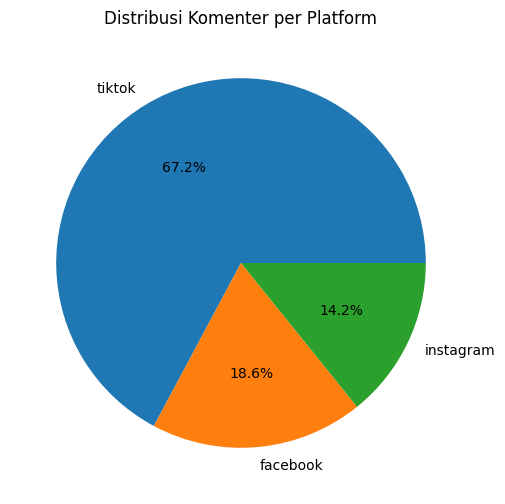

In [15]:
df_thr['platform'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6, 6)
)

plt.title('Distribusi Komenter per Platform')
plt.ylabel('')
plt.savefig('../img/01 Distribusi Komentar per Platform.png')
plt.show()

In [16]:
keywords = [
    'thr', 'asn', 'cair', 'tasik', 'wali',
    'kota', 'walikota', 'pemimpin', 'gaji'
]

keyword_platform = []

for keyword in keywords:
    mask = df_thr['text'].str.contains(
        keyword,
        case=False, # tanpa membedakan kapital/bukan
        na=False,   # nilai kosong dianggap tidak cocok
        regex=False # keyword sebagai teks biasa
    )

    # Hitung jumlah hasil berdsarkan media
    counts = df_thr.loc[mask, 'platform'].value_counts()

    # Menyimpan hasil keyword dan jumlah per media
    keyword_platform.append({
        'keyword': keyword,
        'facebook': counts.get('facebook', 0),
        'instagram': counts.get('instagram', 0),
        'tiktok': counts.get('tiktok', 0)
    })

# List to DF
keyword_platform = pd.DataFrame(keyword_platform)
keyword_platform

,keyword,facebook,instagram,tiktok
0,thr,39,85,158
1,asn,14,35,20
2,cair,10,31,230
3,tasik,42,56,76
4,wali,57,33,33
5,kota,67,59,87
6,walikota,37,19,19
7,pemimpin,4,17,2
8,gaji,4,9,93


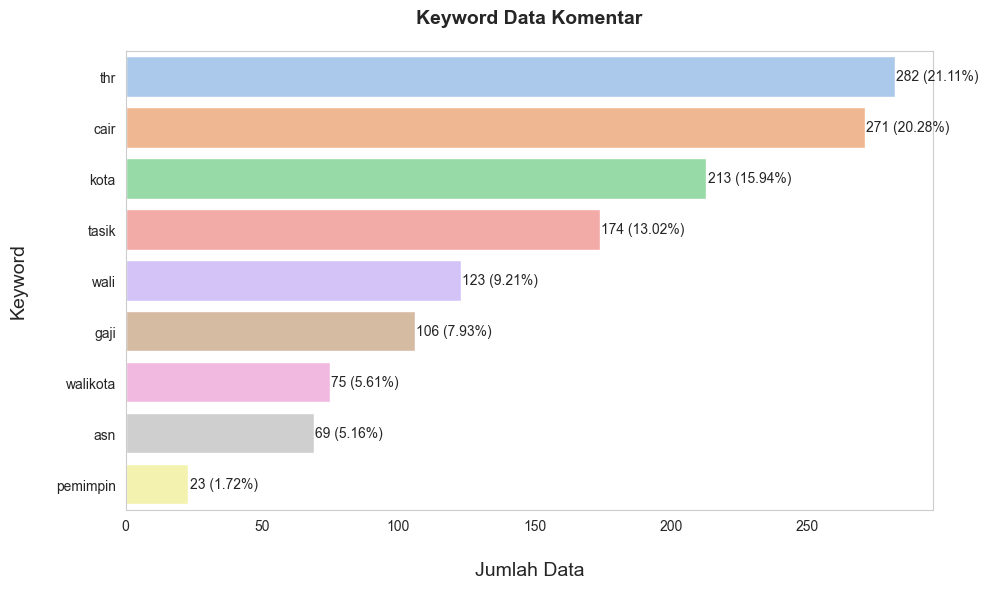

In [17]:
# Hitung total data untuk setiap keyword
keyword_platform['total'] = (
    keyword_platform['facebook'] +
    keyword_platform['instagram'] +
    keyword_platform['tiktok']
)

# Urutkan secara descending
keyword_count = keyword_platform.sort_values('total', ascending=False)

sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(False)

ax = sns.barplot(
    data=keyword_count,
    x='total',
    y='keyword',
    palette='pastel',
    hue='keyword'
)

plt.title('Keyword Data Komentar', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Jumlah Data', labelpad=20, fontsize=14)
plt.ylabel('Keyword', labelpad=20, fontsize=14)

# Total seluruh data keyword
total = keyword_count['total'].sum()

# Tambahkan jumlah dan persentase di ujung bar
for i, count in enumerate(keyword_count['total']):
    percentage = f'{100 * count / total:.2f}%'
    
    ax.text(
        count + 0.5,
        i,
        f'{count} ({percentage})',
        va='center'
    )

plt.tight_layout()
plt.savefig('../img/01 Keyword Data Komentar.png')
plt.show()

In [18]:
df_thr.to_excel('../datasets/01_eda.xlsx', index=False)